# Estimador de RUL — Predicción (versión completa)

**XJTU-SY Bearing Dataset** — rodamientos `1_1`, `1_2`, `1_3`

Este notebook **no entrena nada**. Toma el dataset original (los CSV
crudos de vibración), recalcula sus features y hace dos cosas:

1. **Módulo A — RUL concreto**: carga `model.pkl` (Random Forest ya
   entrenado en `notebook_final_entrenar_modelo`) y predice el RUL en minutos,
   comparándolo contra el valor real.
2. **Módulo B — Evolución del desgaste**: calcula el Health Indicator
   (HI) de `1_2` y usa **ARIMA([1, 5],1,0)** para proyectar cómo evoluciona
   la degradación en los instantes `t=41` y `t=115`.

Requiere que `model.pkl` ya exista (generado por `notebook_final_entrenar_modelo`).


## 0. Configuración e imports

In [2]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
from joblib import Parallel, delayed
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

from statsmodels.tsa.arima.model import ARIMA


In [3]:
# ============================================================
# CONFIGURACIÓN (debe coincidir con notebook_final_entrenar_modelo.ipynb)
# ============================================================
DATASET_ZIP = '/content/sample_data/Bearing1_1-1_2-1_3.zip'
DATASET_DIR = '/content/sample_data/dataset'
MODEL_PATH = '/content/sample_data/model.pkl'

BEARINGS = {
    '1_1': os.path.join(DATASET_DIR, 'Bearing1_1'),
    '1_2': os.path.join(DATASET_DIR, 'Bearing1_2'),
    '1_3': os.path.join(DATASET_DIR, 'Bearing1_3'),
}

FS = 25600
FR = 35.0
N_B, D_B, D_P = 8, 7.92, 34.55
BPFO = N_B / 2 * FR * (1 - D_B / D_P)
BPFI = N_B / 2 * FR * (1 + D_B / D_P)

HEALTHY_FRAC = 0.15
N_COMPONENTS_HI = 8

SOS = signal.butter(4, [2000, 10000], btype='band', fs=FS, output='sos')


In [4]:
def descomprimir_dataset():
    import zipfile
    if os.path.isdir(DATASET_DIR) and any(os.scandir(DATASET_DIR)):
        print('El dataset ya está descomprimido, se omite este paso.')
        return
    with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
        z.extractall(DATASET_DIR)
    print('Dataset descomprimido en', DATASET_DIR)

descomprimir_dataset()

Dataset descomprimido en /content/sample_data/dataset


## 1. Extracción de features (idéntica a la usada en el entrenamiento)

In [5]:
def envelope_feats(x, p):
    env = np.abs(signal.hilbert(signal.sosfiltfilt(SOS, x)))
    env = (env - env.mean()) * np.hanning(len(env))
    spec = np.abs(np.fft.rfft(env)) / len(env)
    freqs = np.fft.rfftfreq(len(env), 1 / FS)
    out = {}
    for k in (1, 2, 3):
        m = (freqs >= k * BPFO - 3) & (freqs <= k * BPFO + 3)
        out[f'{p}_bpfo_h{k}'] = spec[m].max()
    out[f'{p}_bpfo_sum'] = sum(out[f'{p}_bpfo_h{k}'] for k in (1, 2, 3))
    return out


def channel_features(x, p):
    x = x - x.mean()
    rms, peak = np.sqrt(np.mean(x ** 2)), np.max(np.abs(x))
    mabs = np.mean(np.abs(x))
    spec = np.abs(np.fft.rfft(x)) / len(x)
    freqs = np.fft.rfftfreq(len(x), 1 / FS)
    edges = np.linspace(0, FS / 2, 9)
    f = {
        f'{p}_rms': rms, f'{p}_peak': peak, f'{p}_p2p': x.max() - x.min(),
        f'{p}_kurt': stats.kurtosis(x), f'{p}_skew': stats.skew(x),
        f'{p}_crest': peak / rms, f'{p}_shape': rms / mabs, f'{p}_impulse': peak / mabs,
        f'{p}_centroid': np.sum(freqs * spec) / np.sum(spec),
    }
    for i, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
        e = np.sum(spec[(freqs >= a) & (freqs < b)] ** 2)
        f[f'{p}_band{i}'] = np.log10(e + 1e-12)
    f.update(envelope_feats(x, p))
    return f


def snapshot_features(path):
    d = pd.read_csv(path)
    h = d['Horizontal_vibration_signals'].values.astype(np.float64)
    v = d['Vertical_vibration_signals'].values.astype(np.float64)
    return {**channel_features(h, 'h'), **channel_features(v, 'v')}


def process_bearing(name, folder):
    files = sorted(glob.glob(f'{folder}/*.csv'),
                    key=lambda p: int(os.path.basename(p).split('.')[0]))
    rows = Parallel(n_jobs=-1)(delayed(snapshot_features)(f) for f in files)
    df = pd.DataFrame(rows)
    T = len(df)
    df['t'] = np.arange(1, T + 1)
    df['T'] = T
    df['rul'] = T - df['t']
    df['bearing'] = name
    return df


## 2. Cargar el dataset original y el modelo (`model.pkl`)

In [6]:
print('=== Procesando el dataset original (CSV crudos) ===')
df = pd.concat([process_bearing(n, f) for n, f in BEARINGS.items()], ignore_index=True)
feat_cols = [c for c in df.columns if c[:2] in ('h_', 'v_')]
print(df.groupby('bearing').size())


=== Procesando el dataset original (CSV crudos) ===
bearing
1_1    123
1_2    161
1_3    158
dtype: int64


In [7]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'No se encontró {MODEL_PATH}. Corre primero notebook_final_entrenar_modelo.ipynb.')

paquete = joblib.load(MODEL_PATH)
print('Modelo cargado:', paquete.get('tipo_modelo', 'desconocido'))
print('Features esperadas por el modelo:', paquete['features'])
print('RUL_CAP:', paquete.get('rul_cap', 60))


Modelo cargado: desconocido
Features esperadas por el modelo: ['v_band4', 'v_band5', 'v_band2', 'v_band1', 'h_band1', 'h_p2p', 'h_band2', 'v_peak', 'h_band3', 'v_bpfo_h1', 'v_bpfo_sum', 'h_bpfo_h1']
RUL_CAP: 60


## 3. Módulo A — Predicción de RUL con Random Forest

In [8]:
def predecir_dataset(df, paquete):
    """Aplica el modelo cargado a todas las filas de `df` y agrega las
    columnas rul_capped (real, con tope) y rul_predicho."""
    cols = paquete['features']
    rul_cap = paquete.get('rul_cap', 60)

    faltantes = [c for c in cols if c not in df.columns]
    if faltantes:
        raise ValueError(f'Faltan columnas requeridas por el modelo: {faltantes}')

    df = df.copy()
    df['rul_capped'] = df['rul'].clip(upper=rul_cap)
    df['rul_predicho'] = paquete['modelo'].predict(df[cols])
    df['error_abs'] = (df['rul_predicho'] - df['rul_capped']).abs()
    df['error_pct'] = df['error_abs'] / rul_cap * 100   # NMAE por fila
    return df


def marcar_train_test(df, paquete):
    """Etiqueta cada fila como 'train' (vista por el modelo) o 'test'
    (fuera de muestra) usando la metadata guardada en model.pkl."""
    train_bearings = paquete.get('train_bearings', [])
    partial = paquete.get('train_partial', None)

    df = df.copy()
    df['split'] = np.nan
    df.loc[df['bearing'].isin(train_bearings), 'split'] = 'train'

    if partial:
        b, t_max = partial['bearing'], partial['t_max_train']
        df.loc[(df['bearing'] == b) & (df['t'] <= t_max), 'split'] = 'train'
        df.loc[(df['bearing'] == b) & (df['t'] > t_max), 'split'] = 'test'

    df['split'] = df['split'].fillna('desconocido')
    return df


In [10]:
import warnings
warnings.filterwarnings('ignore')

print('=== Prediciendo RUL con el modelo cargado (Random Forest) ===')
df_pred = predecir_dataset(df, paquete)
df_pred = marcar_train_test(df_pred, paquete)

print('\n=== Resumen de error por split ===')
resumen = df_pred.groupby('split').agg(
    MAE_min=('error_abs', 'mean'),
    NMAE_pct=('error_pct', 'mean'),
    n_filas=('error_abs', 'count'),
).round(2)
print(resumen)


=== Prediciendo RUL con el modelo cargado (Random Forest) ===

=== Resumen de error por split ===
       MAE_min  NMAE_pct  n_filas
split                            
test      6.21     10.35       37
train     1.87      3.11      405


In [11]:
print('=== Ejemplos concretos (tramo fuera de muestra) ===')
n_test = min(10, (df_pred.split == 'test').sum())
ejemplos = df_pred[df_pred.split == 'test'].sample(n_test, random_state=0)
cols_mostrar = ['bearing', 't', 'rul_capped', 'rul_predicho', 'error_abs', 'error_pct']
print(ejemplos[cols_mostrar].sort_values('t').to_string(index=False))


=== Ejemplos concretos (tramo fuera de muestra) ===
bearing   t  rul_capped  rul_predicho  error_abs  error_pct
    1_2 127          34     31.412965   2.587035   4.311726
    1_2 135          26     15.627716  10.372284  17.287140
    1_2 136          25     16.956100   8.043900  13.406500
    1_2 140          21     15.176835   5.823165   9.705275
    1_2 141          20     16.311096   3.688904   6.148173
    1_2 145          16     11.518603   4.481397   7.468995
    1_2 147          14     10.549814   3.450186   5.750309
    1_2 150          11      9.991423   1.008577   1.680962
    1_2 153           8      6.812292   1.187708   1.979513
    1_2 156           5      8.776247   3.776247   6.293745


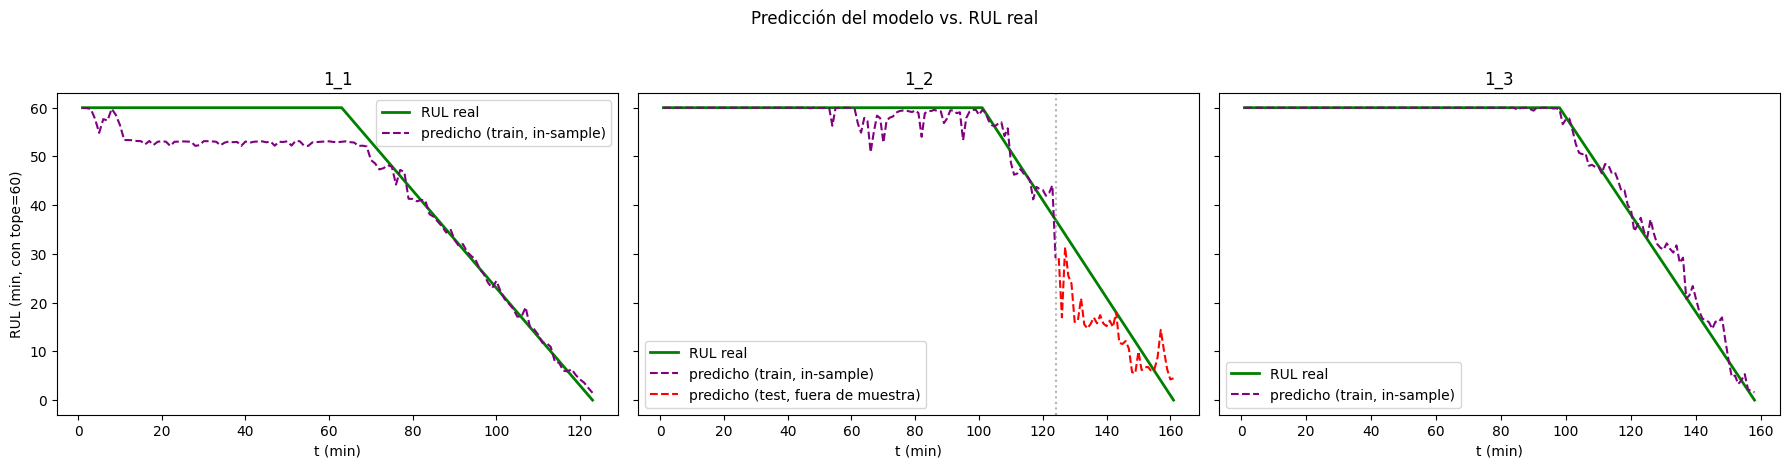

In [12]:
def graficar_predicciones(df, paquete):
    """RUL real vs. predicho por rodamiento, diferenciando train
    (in-sample) de test (fuera de muestra) cuando aplica."""
    bearings = sorted(df['bearing'].unique())
    fig, axes = plt.subplots(1, len(bearings), figsize=(6 * len(bearings), 4.5), sharey=True)
    if len(bearings) == 1:
        axes = [axes]

    for ax, b in zip(axes, bearings):
        g = df[df.bearing == b].sort_values('t')
        ax.plot(g['t'], g['rul_capped'], color='green', linewidth=2, label='RUL real')

        g_train = g[g.split == 'train']
        g_test = g[g.split == 'test']
        if len(g_train):
            ax.plot(g_train['t'], g_train['rul_predicho'], linestyle='--',
                     color='purple', label='predicho (train, in-sample)')
        if len(g_test):
            ax.plot(g_test['t'], g_test['rul_predicho'], linestyle='--',
                     color='red', label='predicho (test, fuera de muestra)')
        if len(g_train) and len(g_test):
            corte = g_train['t'].max()
            ax.axvline(corte, color='gray', linestyle=':', alpha=0.6)

        ax.set_title(b)
        ax.set_xlabel('t (min)')
        ax.legend()

    axes[0].set_ylabel(f"RUL (min, con tope={paquete.get('rul_cap', 60)})")
    plt.suptitle('Predicción del modelo vs. RUL real', y=1.03)
    plt.tight_layout()
    plt.show()


graficar_predicciones(df_pred, paquete)


## 4. Módulo B — Evolución del desgaste de `1_2` con ARIMA([1, 5],1,0)

Para proyectar la degradación necesitamos el **Health Indicator (HI)**,
que no viene guardado en `model.pkl` (es específico de cada trayectoria,
no un artefacto reutilizable como el Random Forest). Por eso se recalcula
aquí a partir de las features ya extraídas.

Se evalúan dos instantes de `1_2`:
- **t=41**: coincide con el FPT detectado de `1_2` (inicio de la degradación).
- **t=115**: un punto más avanzado de la fase de degradación.

In [13]:
def health_indicator_causal(g, feat_cols, healthy_frac=HEALTHY_FRAC,
                              n_components=N_COMPONENTS_HI, smooth=5):
    """HI causal: PCA ajustado solo con la fase sana, con K-Fold dentro
    de esa fase para evitar el salto artificial de borde (ver notebook
    de entrenamiento para la discusión completa)."""
    g = g.sort_values('t').reset_index(drop=True)
    X = g[feat_cols].values
    n_h = max(int(len(X) * healthy_frac), 10)
    n_comp = min(n_components, X.shape[1] - 1, n_h - 2)

    sc = StandardScaler().fit(X[:n_h])
    pca = PCA(n_components=n_comp, random_state=0).fit(sc.transform(X[:n_h]))

    err = np.zeros(len(X))
    if len(X) > n_h:
        Z_rest = sc.transform(X[n_h:])
        recon_rest = pca.inverse_transform(pca.transform(Z_rest))
        err[n_h:] = np.mean((Z_rest - recon_rest) ** 2, axis=1)

    n_splits = max(2, min(5, n_h // 3))
    kf = KFold(n_splits=n_splits, shuffle=False)
    for tr_idx, va_idx in kf.split(X[:n_h]):
        sc_cv = StandardScaler().fit(X[tr_idx])
        n_comp_cv = min(n_comp, len(tr_idx) - 1)
        pca_cv = PCA(n_components=n_comp_cv, random_state=0).fit(sc_cv.transform(X[tr_idx]))
        Zv = sc_cv.transform(X[va_idx])
        rv = pca_cv.inverse_transform(pca_cv.transform(Zv))
        err[va_idx] = np.mean((Zv - rv) ** 2, axis=1)

    hi = pd.Series(err, index=g.index).rolling(smooth, min_periods=1).median()
    base_mean, base_std = err[:n_h].mean(), err[:n_h].std() + 1e-9
    hi_z = (hi - base_mean) / base_std

    out = g[['bearing', 't', 'T', 'rul']].copy()
    out['hi_raw'] = err
    out['hi'] = hi
    out['hi_z'] = hi_z
    return out


# Calculamos el HI solo para 1_2 (la unidad que vamos a proyectar)
g_1_2_raw = df[df.bearing == '1_2']
hi_1_2 = health_indicator_causal(g_1_2_raw, feat_cols)
hi_1_2.head()


,bearing,t,T,rul,hi_raw,hi,hi_z
0,1_2,1,161,160,3.327746,3.327746,3.370900
1,1_2,2,161,159,2.496397,2.912071,2.826247
2,1_2,3,161,158,1.909760,2.496397,2.281595
3,1_2,4,161,157,0.932717,2.203078,1.897264
4,1_2,5,161,156,0.499472,1.909760,1.512932


In [14]:
def graficar_evolucion_arima(hi_df, bearing, t_eval, horizon=15, window=30, order=([1, 5], 1, 0)):
    """Proyecta la evolución del Health Indicator con ARIMA a partir del
    historial disponible hasta el instante t_eval. Si el orden solicitado
    no converge (orden alto + ventana corta), reintenta con (1,1,0)."""
    g = hi_df[hi_df.bearing == bearing].sort_values('t').reset_index(drop=True)
    hi_pos = np.log1p(g['hi_z'].clip(lower=0))

    y_hist = hi_pos.iloc[max(0, t_eval - window):t_eval].values
    y_real_fwd = hi_pos.iloc[t_eval:t_eval + horizon].values

    orden_usado = order
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            res = ARIMA(y_hist, order=order, trend='t').fit()
        forecast_result = res.get_forecast(horizon)
        y_pred_fwd = forecast_result.predicted_mean
        ic = forecast_result.conf_int(alpha=0.20)
    except Exception as e:
        print(f'  ⚠️  ARIMA{order} no convergió ({type(e).__name__}); '
              f'usando ARIMA(1,1,0) como respaldo.')
        orden_usado = (1, 1, 0)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            res = ARIMA(y_hist, order=orden_usado, trend='t').fit()
        forecast_result = res.get_forecast(horizon)
        y_pred_fwd = forecast_result.predicted_mean
        ic = forecast_result.conf_int(alpha=0.20)

    t_hist = g['t'].iloc[max(0, t_eval - window):t_eval].values
    t_fwd = g['t'].iloc[t_eval:t_eval + horizon].values

    plt.figure(figsize=(9, 5))
    plt.plot(t_hist, y_hist, label='Histórico (observado)', color='steelblue', linewidth=2)
    plt.plot(t_fwd, y_real_fwd, label='Real', color='green', linewidth=2)
    plt.plot(t_fwd, y_pred_fwd, label=f'Proyección ARIMA{orden_usado}', linestyle='--', color='red', linewidth=2)
    plt.fill_between(t_fwd, ic[:, 0], ic[:, 1], color='red', alpha=0.15, label='Intervalo de confianza (80%)')
    plt.axvline(t_eval, color='gray', linestyle=':', alpha=0.6)
    plt.title(f'{bearing}: Evolución del desgaste — proyección en t={t_eval}')
    plt.xlabel('Tiempo (min)')
    plt.ylabel('Health Indicator — log(HI+1)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    mae = np.mean(np.abs(y_pred_fwd - y_real_fwd))
    print(f'  Orden usado: ARIMA{orden_usado} | MAE de la proyección ({horizon} min): {mae:.3f}')
    return mae, orden_usado


=== 1_2 — proyección en t=41 (FPT: inicio de la degradación) ===


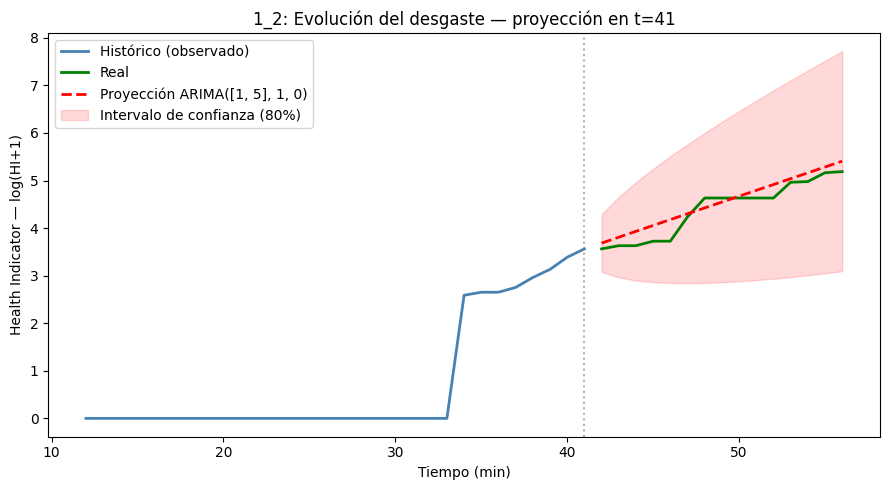

  Orden usado: ARIMA([1, 5], 1, 0) | MAE de la proyección (15 min): 0.188


In [15]:
print('=== 1_2 — proyección en t=41 (FPT: inicio de la degradación) ===')
mae_41, orden_41 = graficar_evolucion_arima(hi_1_2, '1_2', t_eval=41, order=([1, 5], 1, 0))


=== 1_2 — proyección en t=115 (fase de degradación avanzada) ===


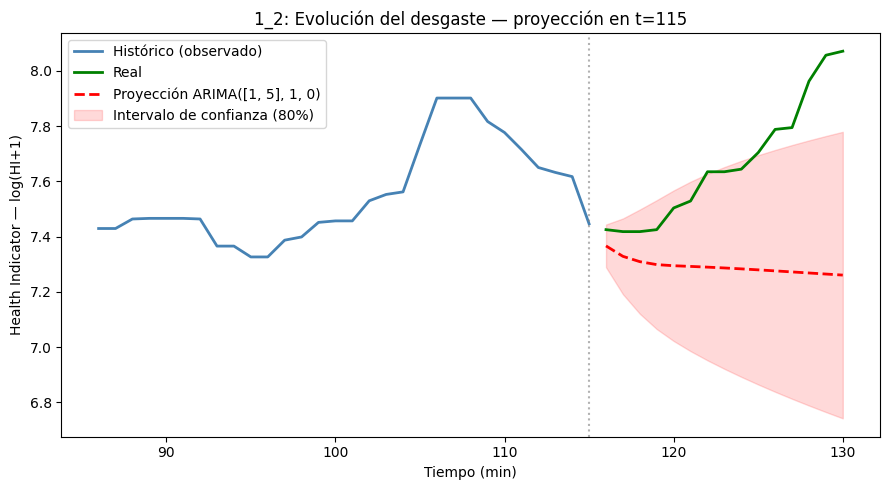

  Orden usado: ARIMA([1, 5], 1, 0) | MAE de la proyección (15 min): 0.376


In [16]:
print('=== 1_2 — proyección en t=115 (fase de degradación avanzada) ===')
mae_115, orden_115 = graficar_evolucion_arima(hi_1_2, '1_2', t_eval=115, order=([1, 5], 1, 0))


In [17]:
print('=== Resumen de la evolución proyectada (1_2) ===')
print(f"  t=41  -> orden usado {orden_41}, MAE = {mae_41:.3f}")
print(f"  t=115 -> orden usado {orden_115}, MAE = {mae_115:.3f}")


=== Resumen de la evolución proyectada (1_2) ===
  t=41  -> orden usado ([1, 5], 1, 0), MAE = 0.188
  t=115 -> orden usado ([1, 5], 1, 0), MAE = 0.376


## 5. Cierre

- **Módulo B (RUL en minutos)**: predicción hecha con el `model.pkl`
  entrenado en `notebook_final_entrenar_modelo.ipynb`, sin reentrenar nada.
- **Módulo A (evolución del desgaste)**: proyección de `1_2` en `t=41`
  y `t=115` con `ARIMA([1, 5],1,0)`, con respaldo automático a `ARIMA(1,1,0)`
  si el orden alto no converge dado el tamaño de la ventana histórica.